In [1]:
from database import postgres_connection
from data_processing_and_visualization import check_column_for_nan, plot_histograms, plot_bars

import pandas as pd

In [2]:
"""
Выгрузка из БД с помощью SQL.
На текущий момент выгрузка реализована с помощью DVC
"""
# QUERY_FEEDS = """
# SELECT *
# FROM feed_data
# WHERE ACTION = 'view'
# ORDER BY timestamp DESC
# LIMIT 5000000
# """

# with postgres_connection() as conn:
#     feeds_df = pd.read_sql(QUERY_FEEDS, conn)

C:\Users\Artem\AppData\Local\Temp\ipykernel_21104\25941147.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  feeds_df = pd.read_sql(QUERY_FEEDS, conn)


In [5]:
feeds_df

,timestamp,user_id,post_id,action,target
0,2021-12-29 23:51:06,64493,3096,view,0
1,2021-12-29 23:51:06,91962,2834,view,0
2,2021-12-29 23:51:06,57667,712,view,0
3,2021-12-29 23:51:06,98970,4254,view,0
4,2021-12-29 23:51:06,33768,1723,view,0
...,...,...,...,...,...
4999995,2021-12-23 14:36:32,84772,1819,view,1
4999996,2021-12-23 14:36:32,133794,3545,view,0
4999997,2021-12-23 14:36:32,98684,3095,view,1
4999998,2021-12-23 14:36:32,113394,1099,view,0


In [6]:
user_features_df = pd.read_parquet('data/user_features.parquet')
post_features_df = pd.read_parquet('data/post_features.parquet')
df_holiday = pd.read_parquet('data/df_holiday.parquet')

# EDA

In [7]:
for col in feeds_df.columns:
    check_column_for_nan(feeds_df, col)

Столбец 'timestamp' не содержит NaN
Столбец 'user_id' не содержит NaN
Столбец 'post_id' не содержит NaN
Столбец 'action' не содержит NaN
Столбец 'target' не содержит NaN


### A. Извлечение фичей из времени

In [8]:
df_final = feeds_df.merge(user_features_df[['user_id', 'country']], on='user_id', how='left')

In [9]:
class TimeFeatureExtractor:
    """Класс для добавления временных фичей к DataFrame."""
    
    def __init__(self, df: pd.DataFrame):
        """
        Инициализация extractor с копированием DataFrame.
        
        Параметры:
            df: исходный DataFrame (со столбцами 'timestamp' и 'country')
        """
        self.df = df.copy()
        self._prepared = False
        self._median_sec = 97
    
    def _prepare_df(self, timestamp_col: str = 'timestamp'):
        """Приводит timestamp к datetime и извлекает дату (вызывается один раз)."""
        if self._prepared:
            return
        
        self.df[timestamp_col] = pd.to_datetime(self.df[timestamp_col])
        self._prepared = True
    
    def add_holiday_flags(self, df_holiday: pd.DataFrame, timestamp_col: str = 'timestamp') -> pd.DataFrame:
        """
        Добавляет столбцы is_holiday к сохранённому df.

        Параметры:
            df_holiday: DataFrame со столбцами 'date' и 'country' (праздники)

        Возвращает:
            DataFrame с добавленными столбцами 'is_holiday'
        """
        # Подготовка df (timestamp -> datetime, извлечение date)
        self._prepare_df()
        
        df_with_date = self.df.copy()
        df_with_date['date'] = pd.to_datetime(df_with_date[timestamp_col]).dt.date
        
        df_holiday = df_holiday.copy()
        df_holiday['date'] = pd.to_datetime(df_holiday['date']).dt.date

        # Определяем is_holiday = 1
        merged = df_with_date.merge(
            df_holiday[['country', 'date']],
            on=['country', 'date'],
            how='left',
            indicator=True
        )
        
        merged['is_holiday'] = (merged['_merge'] == 'both').astype(int)

        # Убираем служебные колонки
        merged = merged.drop(columns=['_merge', 'date'])

        self.df = merged
        
        return self.df
    
    def add_time_of_day(self, timestamp_col: str = 'timestamp') -> pd.DataFrame:
        """
        Добавим столбец с разбиением на время суток.

        Возвращает:
            DataFrame с добавленными столбцами 'time_of_day'
        """
        self._prepare_df()
            
        bins = [0, 6, 12, 18, 24]
        labels = ['night', 'morning', 'day', 'evening']

        self.df['time_of_day'] = pd.cut(self.df[timestamp_col].dt.hour, bins=bins, labels=labels, right=True, include_lowest=True)

        return self.df
    
    def add_time_features(self, timestamp_col: str = 'timestamp') -> pd.DataFrame:
        """
        Добавляет базовые временные фичи из datetime столбца.

        Параметры:
            date_col: имя datetime столбца (по умолчанию 'timestamp')

        Возвращает:
            DataFrame с добавленными временными фичами
        """
        self._prepare_df()
        
        self.df['year'] = self.df[timestamp_col].dt.year
        self.df['month'] = self.df[timestamp_col].dt.month
        self.df['is_month_start'] = self.df[timestamp_col].dt.is_month_start.astype(int)
        self.df['is_month_end'] = self.df[timestamp_col].dt.is_month_end.astype(int)
        self.df['is_weekend'] = self.df[timestamp_col].dt.dayofweek.isin([5, 6]).astype(int)
        
        return self.df
    
    def add_time_since_last_interaction(self, timestamp_col='timestamp', user_id_col='user_id'):
        """
        Добавляет время до предыдущего взаимодействия в секундах.

        Возвращает:
            DataFrame с добавленным столбцом 'time_since_last_interaction_sec'
        """
        
        self._prepare_df()
        
        # Сортируем по user_id и timestamp
        self.df = self.df.sort_values([user_id_col, timestamp_col])
        
        # Вычисляем разницу между текущим и предыдущим timestamp для каждого пользователя
        self.df['time_since_last_interaction_sec'] = self.df.groupby(user_id_col)[timestamp_col].diff().dt.total_seconds()

        # Заполняем NaN медианой в обоих
        self.df['time_since_last_interaction_sec'] = self.df['time_since_last_interaction_sec'].fillna(self._median_sec)
        
        return self.df
    
    def get_df(self) -> pd.DataFrame:
        """Возвращает текущий (возможно модифицированный) DataFrame."""
        
        return self.df


In [10]:
extractor = TimeFeatureExtractor(df_final)
extractor.add_time_features()
extractor.add_holiday_flags(df_holiday)
extractor.add_time_of_day()
extractor.add_time_since_last_interaction()

df_final = extractor.get_df()
df_final = df_final.drop('country', axis=1)

In [11]:
df_final

,timestamp,user_id,post_id,action,target,year,month,is_month_start,is_month_end,is_weekend,is_holiday,time_of_day,time_since_last_interaction_sec
4285881,2021-12-24 13:43:12,200,4420,view,0,2021,12,0,0,0,0,day,97.0
4285086,2021-12-24 13:44:22,200,2629,view,0,2021,12,0,0,0,0,day,70.0
4284883,2021-12-24 13:44:42,200,2252,view,0,2021,12,0,0,0,0,day,20.0
4284005,2021-12-24 13:45:37,200,3988,view,0,2021,12,0,0,0,0,day,55.0
4283185,2021-12-24 13:47:10,200,2879,view,0,2021,12,0,0,0,0,day,93.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4970514,2021-12-23 15:20:20,168551,5021,view,0,2021,12,0,0,0,0,day,66.0
4969646,2021-12-23 15:21:56,168551,1748,view,0,2021,12,0,0,0,0,day,96.0
4969445,2021-12-23 15:22:10,168551,1414,view,0,2021,12,0,0,0,0,day,14.0
4968856,2021-12-23 15:23:02,168551,3886,view,0,2021,12,0,0,0,0,day,52.0


In [12]:
columns_to_convert = ['target', 'month', 'year']
df_final[columns_to_convert] = df_final[columns_to_convert].astype(object)

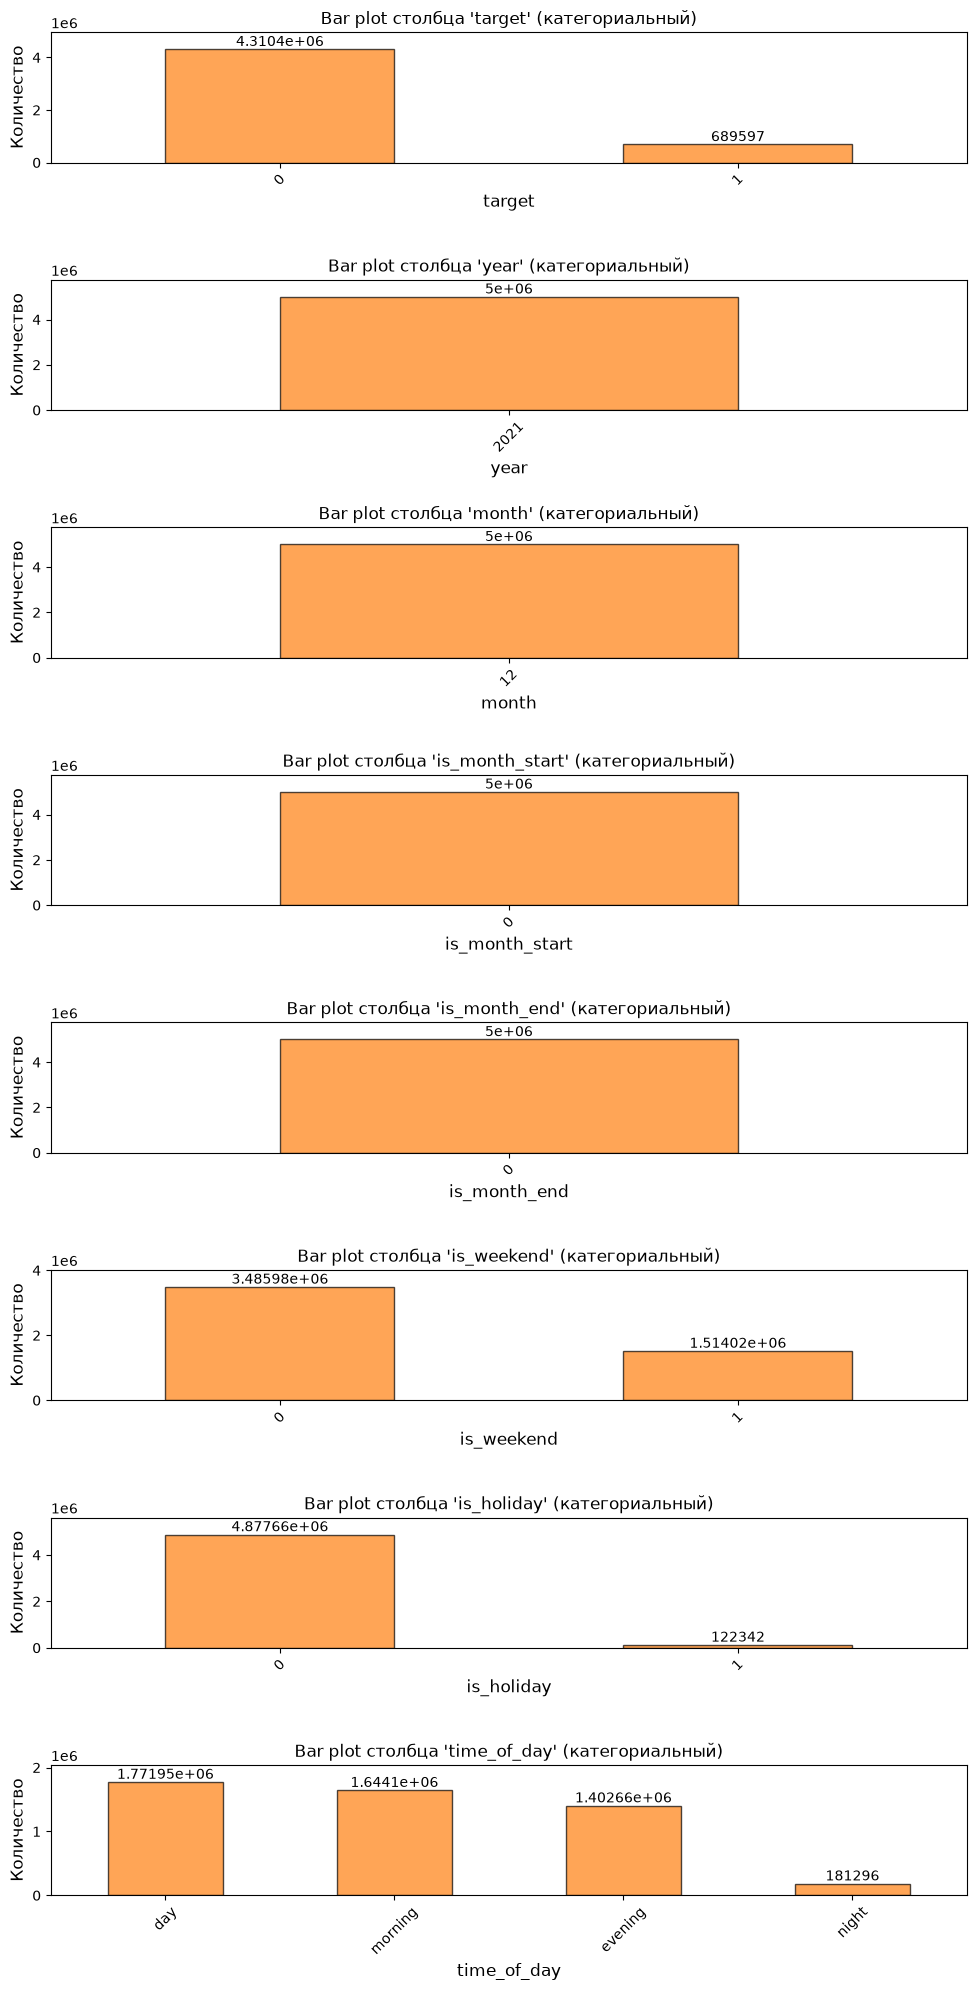

In [13]:
plot_bars(df_final, list(filter(lambda x: x not in ['timestamp', 'user_id', 'post_id', 'action', 'time_since_last_interaction_sec'], df_final.columns)), bins=20, figsize = (10, 20))

### A. Выводы:
1) Фичи с флагами ожидаемо имеют сильно смещение
2) Ввиду того, что данные практически не охватывает все месяца, фича будет удалена
3) Фичу год необходимо удалить, т.к. имеет константное значение

In [14]:
df_final = df_final.drop(['year', 'month', 'is_month_start', 'is_month_end'], axis=1)

In [15]:
df_final = df_final.merge(user_features_df, on='user_id', how='left')
df_final = df_final.merge(post_features_df, on='post_id', how='left')

In [16]:
int_cols = df_final.select_dtypes(include="int64").columns
float_cols = df_final.select_dtypes(include="float64").columns

df_final[int_cols] = df_final[int_cols].astype("int32")
df_final[float_cols] = df_final[float_cols].astype("float32")

In [17]:
# Разделение по дате (80% train, 20% test)
split_date = df_final['timestamp'].quantile(0.8)

df_train = df_final[df_final['timestamp'] < split_date].copy()
df_test = df_final[df_final['timestamp'] >= split_date].copy()

# EDA ОБУЧАЮЩЕГО ДАТАСЕТА

In [18]:
df_train

,timestamp,user_id,post_id,action,target,is_weekend,is_holiday,time_of_day,time_since_last_interaction_sec,gender,...,tfidf_svd_90,tfidf_svd_91,tfidf_svd_92,tfidf_svd_93,tfidf_svd_94,tfidf_svd_95,tfidf_svd_96,tfidf_svd_97,tfidf_svd_98,tfidf_svd_99
0,2021-12-24 13:43:12,200,4420,view,0,0,0,day,97.0,1,...,-0.046823,0.016942,-0.023177,-0.035609,-0.004526,0.007175,0.005795,0.028645,-0.046581,0.038345
1,2021-12-24 13:44:22,200,2629,view,0,0,0,day,70.0,1,...,0.016317,0.041660,-0.006078,0.003585,-0.001679,0.028967,-0.063402,-0.016768,-0.011125,0.000955
2,2021-12-24 13:44:42,200,2252,view,0,0,0,day,20.0,1,...,0.014683,0.009724,0.012098,0.000043,0.022676,-0.019320,0.001797,0.014705,-0.021332,-0.044422
3,2021-12-24 13:45:37,200,3988,view,0,0,0,day,55.0,1,...,-0.044405,0.039424,-0.012414,-0.031082,-0.025736,-0.001761,0.000616,0.035083,0.059009,-0.045402
4,2021-12-24 13:47:10,200,2879,view,0,0,0,day,93.0,1,...,-0.001037,0.012636,-0.010574,0.007547,0.001191,-0.003740,0.002163,-0.020662,0.010548,-0.006534
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,2021-12-23 15:20:20,168551,5021,view,0,0,0,day,66.0,0,...,0.025488,-0.048962,0.042460,-0.012211,0.011652,-0.007410,0.000946,-0.000484,0.003547,-0.016013
4999996,2021-12-23 15:21:56,168551,1748,view,0,0,0,day,96.0,0,...,-0.052677,0.006643,0.055252,-0.017017,0.019884,-0.045962,0.019485,-0.021864,0.012690,0.000048
4999997,2021-12-23 15:22:10,168551,1414,view,0,0,0,day,14.0,0,...,0.019760,0.035595,-0.016362,0.009999,-0.014621,-0.001444,0.036903,-0.012471,0.004626,-0.000677
4999998,2021-12-23 15:23:02,168551,3886,view,0,0,0,day,52.0,0,...,-0.011373,0.001426,0.017539,-0.017384,-0.026501,-0.000839,0.019946,-0.022760,-0.005306,0.014886


In [19]:
df_train[['time_since_last_interaction_sec', 'age', 'text_len', 'avg_word_len']].describe()

,time_since_last_interaction_sec,age,text_len,avg_word_len
count,3.999968e+06,3.999968e+06,3.999968e+06,3.999968e+06
mean,1.778086e+03,2.718877e+01,1.363307e+03,6.157817e+00
std,1.865172e+04,1.022373e+01,1.316245e+03,1.104607e+00
min,1.000000e+01,1.400000e+01,3.000000e+01,4.538462e+00
25%,5.300000e+01,1.900000e+01,2.560000e+02,5.565217e+00
50%,9.700000e+01,2.400000e+01,1.073000e+03,5.840336e+00
75%,1.370000e+02,3.300000e+01,1.977000e+03,6.227891e+00
max,4.355790e+05,9.500000e+01,2.539200e+04,1.857143e+01


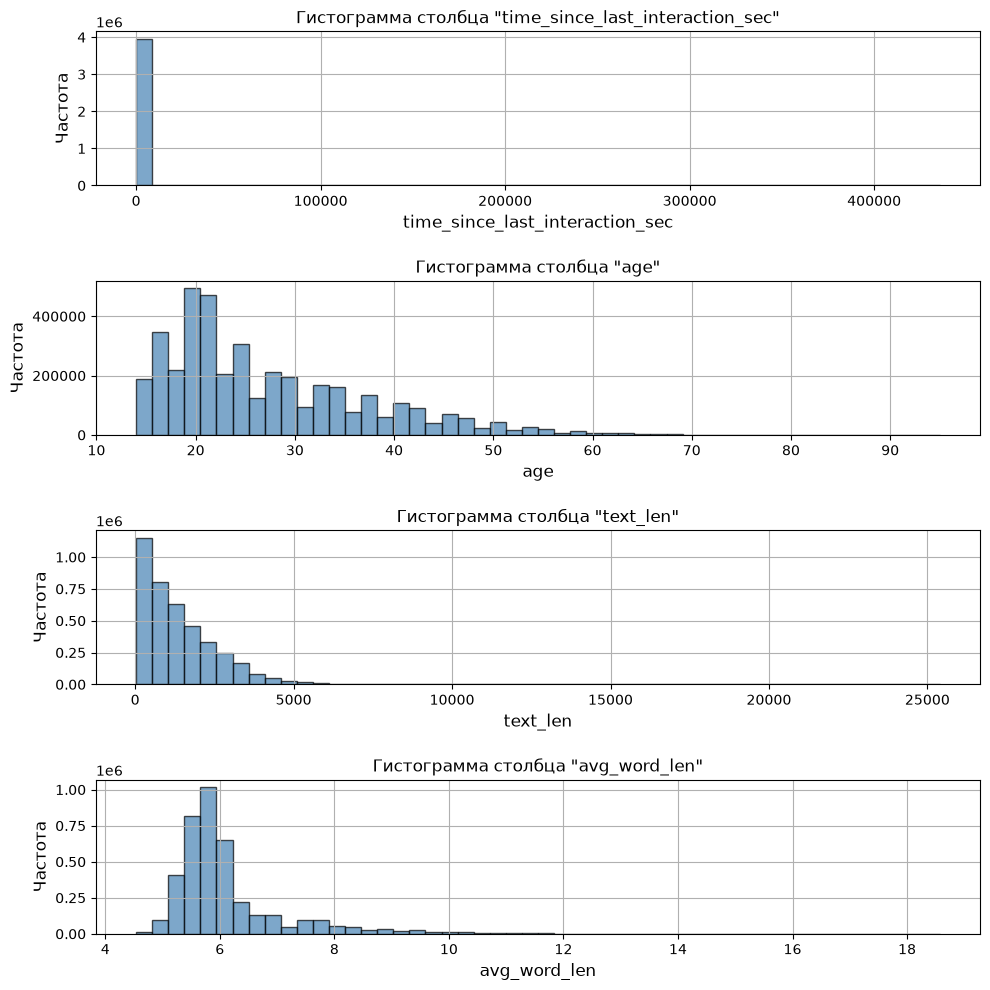

In [20]:
plot_histograms(df_train, ['time_since_last_interaction_sec', 'age', 'text_len', 'avg_word_len', 'freq_city', 'freq_city_in_country'], bins=50, figsize = (10, 10))

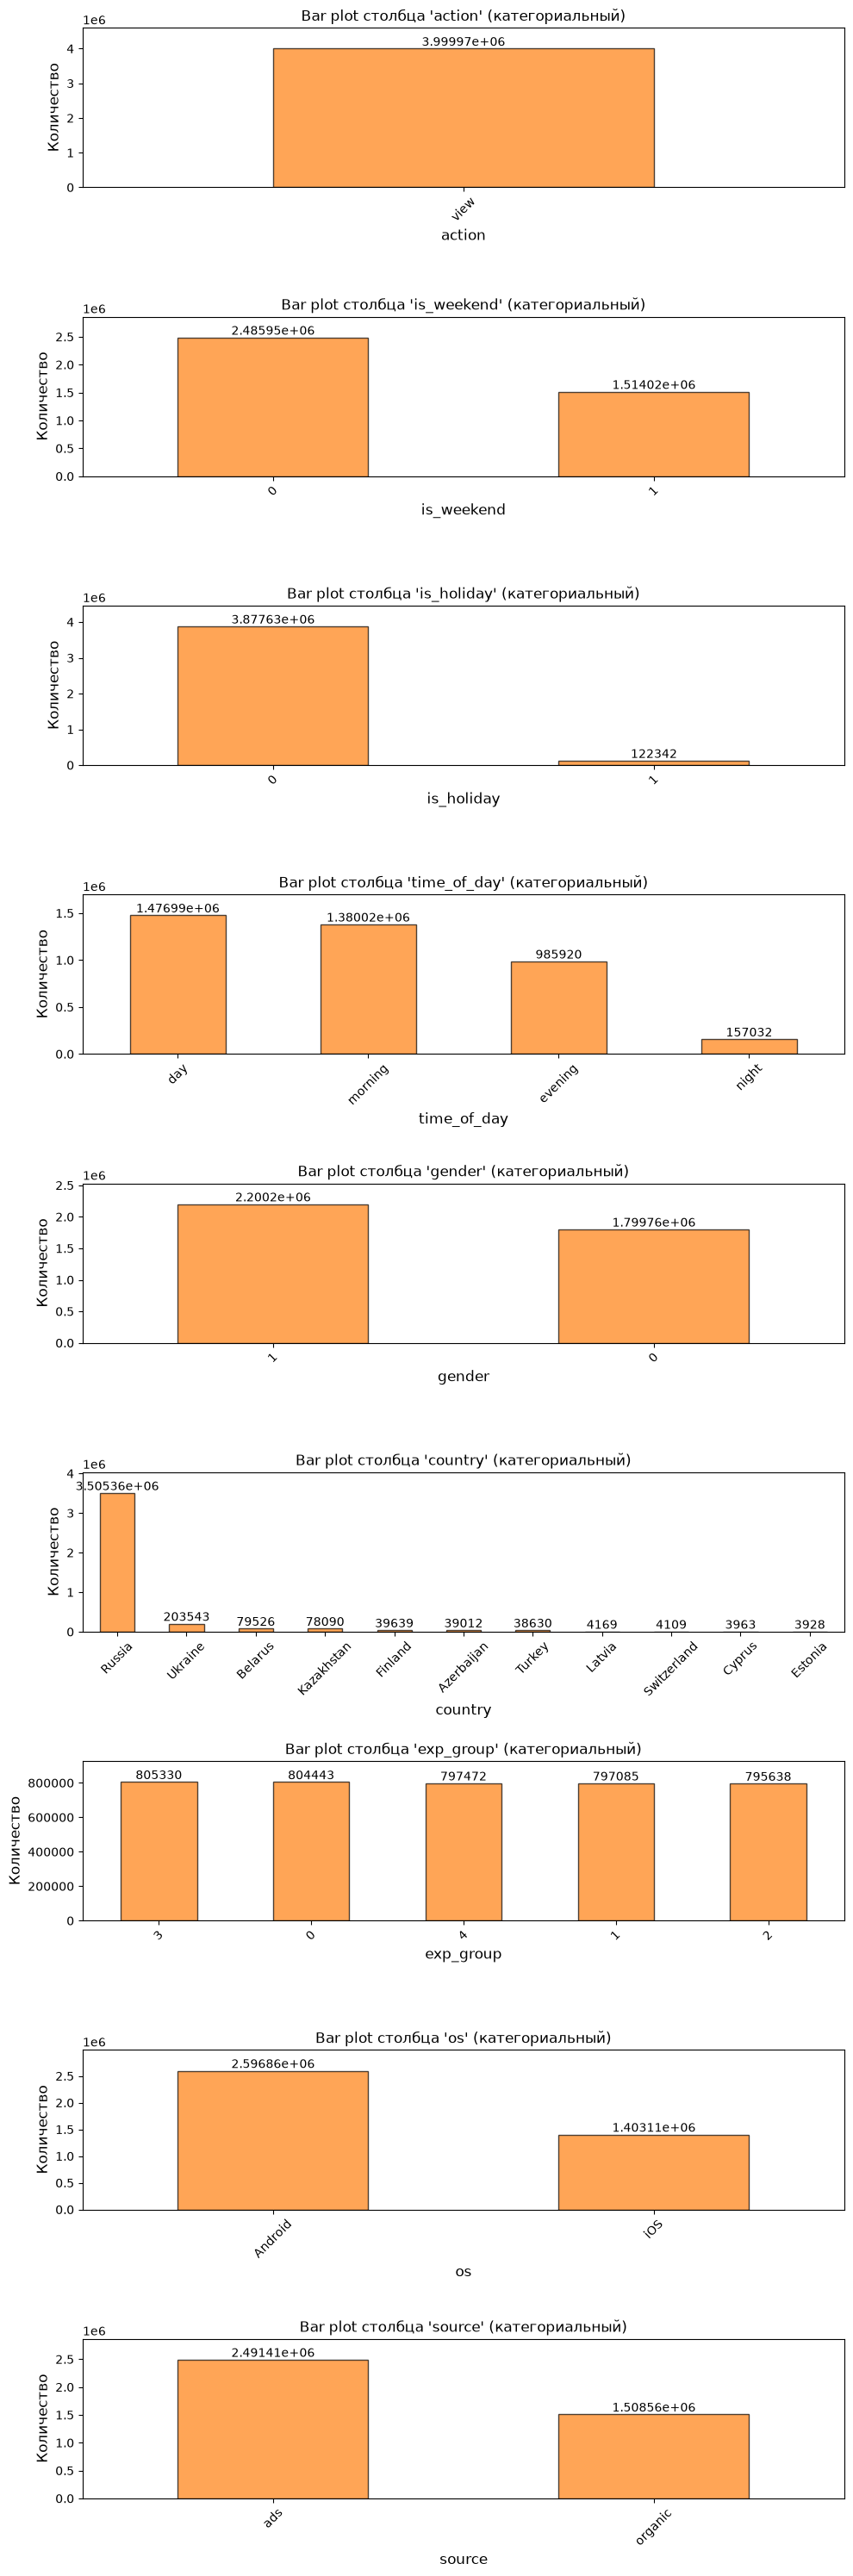

In [21]:
plot_bars(df_train, ['action', 'is_weekend', 'is_holiday', 'time_of_day', 'gender', 'country', 'exp_group', 'os', 'source'], bins=20, figsize = (10, 30))

### Вывод
Все фичи преобладают не в константном значении в обучающем датасете

In [22]:
features_columns = [col for col in df_train.columns if col not in ['timestamp', 'user_id', 'post_id', 'target', 'action']]

target_column = 'target'

In [23]:
X_train, y_train = df_train[features_columns], df_train[[target_column]]
X_test, y_test = df_test[features_columns], df_test[[target_column]]

In [24]:
X_train.to_parquet("data/X_train_full.parquet", compression='snappy')
y_train.to_parquet("data/y_train_full.parquet", compression='snappy')

X_test.to_parquet("data/X_test_full.parquet", compression='snappy')
y_test.to_parquet("data/y_test_full.parquet", compression='snappy')